In [1]:
import numpy as np
from scipy.integrate import odeint
import sympy as smp

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from ipywidgets import interact

# Van der Pol

## Symbolic solution

In [13]:
x1, x2, mu, w, t, alp, F= smp.symbols(r'x_1 x_2 \mu \omega t \alpha \mathcal{F}')

# sin = (w*t) - (w*t)**3/(3*2) + (w*t)**5/(5*4*3*2) - (w*t)**7/(7*6*5*4*3*2) 

dx1 = x2
dx2 = -x1 + mu*x2*(1-x1**2) + alp*smp.sin(w*t)
dt = 1

### Jacobian about origin

In [5]:
Jac = smp.Matrix([[smp.diff(dx1,x1),smp.diff(dx1,x2),smp.diff(dx1,t)],
                  [smp.diff(dx2,x1),smp.diff(dx2,x2),smp.diff(dx2,t)],
                  [smp.diff(dt,x1),smp.diff(dt,x2),smp.diff(dt,t)]])
Jac

Matrix([
[                 0,                1,                           0],
[-2*\mu*x_1*x_2 - 1, \mu*(1 - x_1**2), \alpha*\omega*cos(\omega*t)],
[                 0,                0,                           0]])

In [6]:
J0 = Jac.subs([[x1,0],[x2,0],[mu,1]])
J0

Matrix([
[ 0, 1,                           0],
[-1, 1, \alpha*\omega*cos(\omega*t)],
[ 0, 0,                           0]])

In [7]:
J0.eigenvects()

[(0,
  1,
  [Matrix([
   [\alpha*\omega*cos(\omega*t)],
   [                          0],
   [                          1]])]),
 (1/2 - sqrt(3)*I/2,
  1,
  [Matrix([
   [2*I/(sqrt(3) + I)],
   [                1],
   [                0]])]),
 (1/2 + sqrt(3)*I/2,
  1,
  [Matrix([
   [-2*I/(sqrt(3) - I)],
   [                 1],
   [                 0]])])]

In [8]:
J0.eigenvals()

{0: 1, 1/2 - sqrt(3)*I/2: 1, 1/2 + sqrt(3)*I/2: 1}

### Manifold

In [44]:
x1, x2, mu, w, t, alp, F= smp.symbols(r'x_1 x_2 \mu \omega t \alpha \mathcal{F}')

sin = (w*t) - (w*t)**3/(3*2) #+ (w*t)**5/(5*4*3*2) - (w*t)**7/(7*6*5*4*3*2) 

dx1 = x2
dx2 = (-x1 + mu*x2*(1-x1**2) + alp*sin).expand()
dt = 1

In [45]:
# c, s, u, k1, k2, k3, k4, k5 = smp.symbols(r'c s u \kappa_1 \kappa_2 \kappa_3 \kappa_4 \kappa_5')

# csu = smp.Matrix([c,s,u])
# xyt = smp.Matrix([x_1,x_2,t])

In [46]:
A = dx1.coeff(x1,1).coeff(x2,0).coeff(t,0).coeff(alp,0)
A

0

In [47]:
g1 = dx1 - A*x1
g1

x_2

In [102]:
b1 = dx2.coeff(x1,0).coeff(x2,1).coeff(t,0).coeff(alp,0)
g2_1 = dx2 - b1*x2

b2 = 0
g2_2 = 1

In [103]:
B = smp.Matrix([[b1,0],
                [0,b2]])
B

Matrix([
[\mu, 0],
[  0, 0]])

In [104]:
g2 = smp.Matrix([g2_1,g2_2])
g2

Matrix([
[-\alpha*\omega**3*t**3/6 + \alpha*\omega*t - \mu*x_1**2*x_2 - x_1],
[                                                                1]])

In [105]:
k1, k2, k3, b1, b2, b3 = smp.symbols(r'\kappa_1 \kappa_2 \kappa_3 \beta_1 \beta_2 \beta_3')

h1 = k1*x1**2 + k2*x1*alp + k3*alp**2
h2 = b1*x1**2 + b2*x1*alp + b3*alp**2

H = smp.Matrix([h1,h2])
Dh = smp.diff(H,x1)

In [112]:
g1

x_2

In [106]:
g2

Matrix([
[-\alpha*\omega**3*t**3/6 + \alpha*\omega*t - \mu*x_1**2*x_2 - x_1],
[                                                                1]])

In [111]:
N = Dh*(A*x1 + g1) - B@H - g2
N = N.expand()
N

Matrix([
[-\alpha**2*\kappa_3*\mu - \alpha*\kappa_2*\mu*x_1 + \alpha*\kappa_2*x_2 + \alpha*\omega**3*t**3/6 - \alpha*\omega*t - \kappa_1*\mu*x_1**2 + 2*\kappa_1*x_1*x_2 + \mu*x_1**2*x_2 + x_1],
[                                                                                                                                           \alpha*\beta_2*x_2 + 2*\beta_1*x_1*x_2 - 1]])

In [108]:
N1 = N[0].expand()
N2 = N[1].expand()

In [109]:
N1

\alpha**7*\beta_3**3*\omega**3/6 + \alpha**6*\beta_2*\beta_3**2*\omega**3*x_1/2 + \alpha**5*\beta_1*\beta_3**2*\omega**3*x_1**2/2 + \alpha**5*\beta_2**2*\beta_3*\omega**3*x_1**2/2 + \alpha**4*\beta_1*\beta_2*\beta_3*\omega**3*x_1**3 + \alpha**4*\beta_2**3*\omega**3*x_1**3/6 + \alpha**3*\beta_1**2*\beta_3*\omega**3*x_1**4/2 + \alpha**3*\beta_1*\beta_2**2*\omega**3*x_1**4/2 - \alpha**3*\beta_3*\omega + \alpha**3*\kappa_2*\kappa_3 + \alpha**2*\beta_1**2*\beta_2*\omega**3*x_1**5/2 - \alpha**2*\beta_2*\omega*x_1 + 2*\alpha**2*\kappa_1*\kappa_3*x_1 + \alpha**2*\kappa_2**2*x_1 + \alpha**2*\kappa_3*\mu*x_1**2 - \alpha**2*\kappa_3*\mu + \alpha*\beta_1**3*\omega**3*x_1**6/6 - \alpha*\beta_1*\omega*x_1**2 + 3*\alpha*\kappa_1*\kappa_2*x_1**2 + \alpha*\kappa_2*\mu*x_1**3 - \alpha*\kappa_2*\mu*x_1 + 2*\kappa_1**2*x_1**3 + \kappa_1*\mu*x_1**4 - \kappa_1*\mu*x_1**2 + x_1

In [110]:
N2

\alpha**3*\beta_2*\kappa_3 + 2*\alpha**2*\beta_1*\kappa_3*x_1 + \alpha**2*\beta_2*\kappa_2*x_1 + 2*\alpha*\beta_1*\kappa_2*x_1**2 + \alpha*\beta_2*\kappa_1*x_1**2 + 2*\beta_1*\kappa_1*x_1**3 - 1

In [92]:
N1.coeff(x1,1)

\alpha**6*\beta_2*\beta_3**2*\omega**3/2 - \alpha**2*\beta_2*\omega + 2*\alpha**2*\kappa_1*\kappa_3 + \alpha**2*\kappa_2**2 - \alpha*\kappa_2*\mu + 1

In [68]:
N[0].coeff(x1,1).coeff(alp,1)

-\kappa_2*\mu

In [159]:
dx1_f = smp.lambdify([x1,x2,t,mu,alp,w],dx1)
dx2_f = smp.lambdify([x1,x2,t,mu,alp,w],dx2)

In [160]:
x1v = np.linspace(-10,10,20)/2
x2v = np.linspace(-10,10,20)/2

x1G, x2G = np.meshgrid(x1v,x2v)

In [183]:
mu_val = 1
w_val = 1.2
a_val = 0
F_val = np.linspace(0,1,25)
t_val = np.linspace(0,10*np.pi,1000)

## Numerical solution

In [2]:
clr = ['cornflowerblue',
      'gold',
      'tomato',
      'dimgray']

In [309]:
def poincare(data,t,border,plot_y = True):
    if plot_y ==True:
        x, y = data
        xlim, ylim = border
    else:
        y, x = data
        ylim, xlim = border

    x_mapped = np.where(np.round(x,0)==xlim)[0]
    y = y[x_mapped]
    t_poin = t[x_mapped]
    y_mapped = np.where(y>ylim[0])[0]
    y = y[y_mapped]
    t_poin = t_poin[y_mapped]
    
    return [t_poin,y]
    

Eigenvalue pair

$$\frac{\mu}{2} \pm \frac{\sqrt{(\mu - 2)*(\mu + 2)}}{2}$$

When $\mu=1$

$$\frac{1}{2} \pm \frac{\sqrt{3}}{2}\mathcal{i}$$

In [9]:
w = 1.2
A_space = np.arange(0,1.02,0.05)
kick_time = np.linspace(2*np.pi/w,4*np.pi/w,8)

def kick(t,t0,A):
    sigma = 0.2
    return A/(np.sqrt(2*np.pi)*sigma)*np.exp(-((t-t0)/sigma)**2/2)

def force(t,A):
    return A*np.sin(w*t)


def sys(S,t):
    x1, x2 = S
    
    mu = 1
    AF = A_space[8]
    Ak = 0
    t0 = kick_time[0]

    
    dx1 = x2 
    dx2 = force(t,AF) + mu*x2*(1-x1**2)-x1 + kick(t,t0,Ak)
    
    return [dx1,dx2]

In [10]:
T0 = 2*np.pi/(np.sqrt(3)/2)

In [11]:
t = np.linspace(0,20*T0,10000)

X0 = [0,1]

SS = [2.0086198296834326,0]
# SS

soln = odeint(sys,SS,t).T

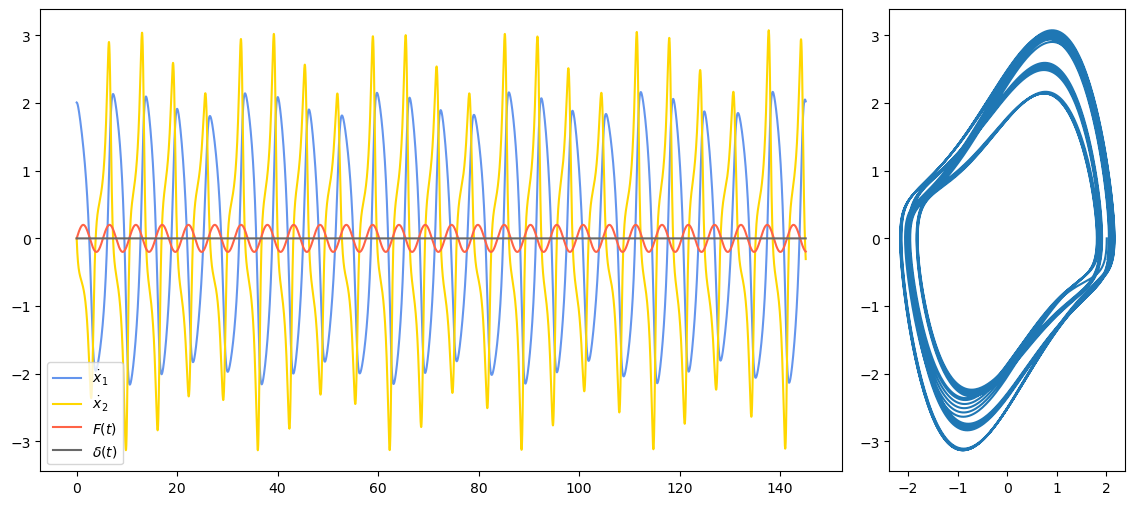

In [12]:
fig = plt.figure(figsize=(14,6))

gs = gridspec.GridSpec(1,4)

p1 = fig.add_subplot(gs[:3])
p2 = fig.add_subplot(gs[3:])


p1.plot(t,soln[0],color=clr[0],label=r'$\dot x_1$')
p1.plot(t,soln[1],color=clr[1],label=r'$\dot x_2$')
p1.plot(t,force(t,A_space[4]),color=clr[2],label=r'$F(t)$')
p1.plot(t,kick(t,kick_time[0],0),color=clr[-1],label=r'$\delta(t)$')



p1.legend()

p2.plot(soln[0],soln[1])
# p2.set_xlim([1.8,2.1])
# p2.set_ylim([-0.5,0.5])
# p2.vlines(0,ymin=ylim[0],ymax=ylim[1],color=clr[-1],linestyle='--')



plt.show()

In [176]:
x = soln[0]
y = soln[1]

ones = np.where(x>=1)[0]

x_map = x[ones]
y_map = y[ones]
t_map = t[ones]



pos = np.where(y_map>0)[0]

x_map = x_map[pos]
y_map = y_map[pos]
t_map = t_map[pos]

gap = np.where(np.diff(pos)>1)[0]

x_map = x_map[gap+1]
y_map = y_map[gap+1]
t_map = t_map[gap+1]

In [177]:
y_map.shape

(21,)

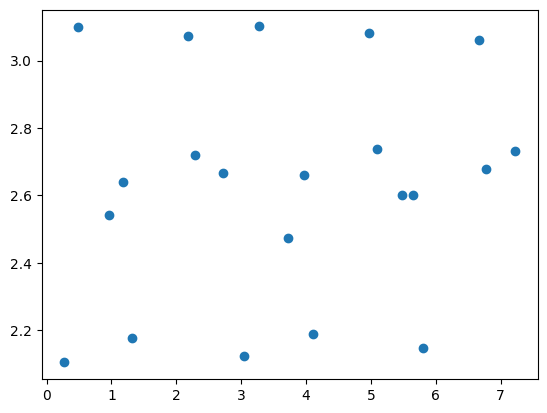

In [182]:
plt.scatter(t_map%(T0),y_map)

In [83]:
vector = np.diff(y)/np.diff(x)
zero_slope = np.where(np.round(vector,1)==0)
zero_slope

(array([ 178,  408,  633,  854, 1075, 1076, 1303, 1538, 1776, 2009, 2010,
        2237, 2459, 2679, 2680, 2904, 3135, 3136, 3373, 3609, 3839, 4063,
        4064, 4284, 4285, 4506, 4507, 4734, 4970, 5207, 5208, 5441, 5667,
        5668, 5889, 5890, 6110, 6335, 6567, 6805, 7041, 7270, 7494, 7715,
        7937, 8165, 8166, 8401, 8402, 8639, 8872, 9098, 9320, 9541, 9766]),)

In [670]:
S0 = [SS[0],SS[1],
A_space[4],0.1,kick_time[0]]

soln = odeint(sys,S0,t).T

In [300]:
test[1]

[-1, 1]

# Duffing Oscillator

Unforced, undamped

$$\ddot{x} - x + x^3 =0$$  

When linearized

$$\begin{cases}\dot x_1 = x_2\\
\dot x_2 = x_1 - x_1^3 - \delta x_2\end{cases}$$

Modified equation [[ch 4, Wiggins]] 

$$\begin{cases}\dot x_1 = x_2\\
\dot x_2 = x_1 - x_1^3 - \delta x_2 + x_1^2x_2\end{cases}$$


Define symbolic system

In [114]:
x1, x2, dta, w, t, alp, F = smp.symbols(r'x_1 x_2 \delta \omega t \alpha \mathcal{F}')

dx1 = x2
dx2 = x1 - x1**3 - dta*x2 + alp*(F) + x1**2*x2

In [115]:
sin = (w*t) - (w*t)**3/(3*2) + (w*t)**5/(5*4*3*2) - (w*t)**7/(7*6*5*4*3*2) 

In [116]:
dx2 = dx2.subs(F,sin)

### Check Zeros

In [64]:
# fix_pnts = smp.solve([dx1,dx2],[x1,x2])
# fix_pnts

### Jac-ob

In [117]:
Jac = smp.Matrix([[smp.diff(dx1,x1),smp.diff(dx1,x2),smp.diff(dx1,t)],
                  [smp.diff(dx2,x1),smp.diff(dx2,x2),smp.diff(dx2,t)],
                  [smp.diff(dt,x1),smp.diff(dt,x2),smp.diff(dt,t)]])
Jac

Matrix([
[                        0,                1,                                                                            0],
[-3*x_1**2 + 2*x_1*x_2 + 1, -\delta + x_1**2, \alpha*(-\omega**7*t**6/720 + \omega**5*t**4/24 - \omega**3*t**2/2 + \omega)],
[                        0,                0,                                                                            0]])

In [118]:
J0 = Jac.subs([[x1,0],[x2,0],[dta,0]])
J0

Matrix([
[0, 1,                                                                            0],
[1, 0, \alpha*(-\omega**7*t**6/720 + \omega**5*t**4/24 - \omega**3*t**2/2 + \omega)],
[0, 0,                                                                            0]])

In [120]:
J0.eigenvects()

[(-1,
  1,
  [Matrix([
   [-1],
   [ 1],
   [ 0]])]),
 (0,
  1,
  [Matrix([
   [\alpha*\omega**7*t**6/720 - \alpha*\omega**5*t**4/24 + \alpha*\omega**3*t**2/2 - \alpha*\omega],
   [                                                                                             0],
   [                                                                                             1]])]),
 (1,
  1,
  [Matrix([
   [1],
   [1],
   [0]])])]

In [121]:
ev1 = J0.eigenvects()[1][2][0]
ev2 = J0.eigenvects()[0][2][0]
ev3 = J0.eigenvects()[2][2][0]

In [122]:
c, s, u = smp.symbols(r'c s u')

csu = smp.Matrix([c,s,u])
xxt = smp.Matrix([x1,x2,t])
P = smp.Matrix([[ev1.T],
                [ev2.T],
                [ev3.T]]).T
Pinv = P.inv()

In [123]:
trans = P@csu
trans

Matrix([
[c*(\alpha*\omega**7*t**6/720 - \alpha*\omega**5*t**4/24 + \alpha*\omega**3*t**2/2 - \alpha*\omega) - s + u],
[                                                                                                     s + u],
[                                                                                                         c]])

In [124]:
csu_dot = Pinv@xxt.subs([[x1,dx1],[x2,dx2],[t,dt]])
csu_dot

Matrix([
[                                                                                                                                                                                                            1],
[                                                                                                            \alpha*\omega**7*t**6/1440 - \alpha*\omega**5*t**4/48 + \alpha*\omega**3*t**2/4 - \alpha*\omega/2],
[-\alpha*\omega**7*t**6/1440 + \alpha*\omega**5*t**4/48 - \alpha*\omega**3*t**2/4 + \alpha*\omega/2 + \alpha*(-\omega**7/5040 + \omega**5/120 - \omega**3/6 + \omega) - \delta*x_2 - x_1**3 + x_1**2*x_2 + x_1]])

In [125]:
csu_dot = csu_dot.subs([[x1,trans[0]],
                        [x2,trans[1]],
                        [t,trans[2]]])
csu_dot

Matrix([
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             1],
[                                                                                                                                                                                                                                                                                                                                                                                                                                             \alpha*\omega**7*c**6/1440 - \a

In [126]:
dc = csu_dot[0].expand()
ds = csu_dot[1].expand()
du = csu_dot[2].expand()

In [127]:
A = dc.coeff(c,1).coeff(s,0).coeff(u,0)
g1 = A - dc*c

In [128]:
Bs = ds.coeff(c,0).coeff(s,1).coeff(u,0)
g2s = Bs - ds*s

In [129]:
Bu = du.coeff(c,0).coeff(s,0).coeff(u,1)
g2u = Bu - du*u

In [131]:
B = smp.Matrix([[Bs,0],[0,Bu]])
g2 = smp.Matrix([[g2s],[g2u]])
B

Matrix([
[0,          0],
[0, 1 - \delta]])

In [108]:
k1, k2, k3, k4, k5, k6 = smp.symbols(r'\kappa_1 \kappa_2 \kappa_3 \kappa_4 \kappa_5 \kappa_6')

h = k1*c**2 + k2*c**3 

\kappa_1